In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("emails.csv")

In [9]:
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB


In [11]:
df.isnull().sum()

text    0
spam    0
dtype: int64

In [12]:
print("Rows and Columns:", df.shape)

Rows and Columns: (5728, 2)


In [13]:
df["spam"].value_counts()

spam
0    4360
1    1368
Name: count, dtype: int64

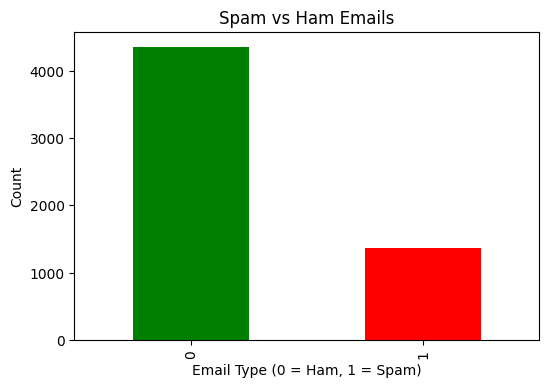

In [14]:
plt.figure(figsize=(6,4))

df["spam"].value_counts().plot(
    kind="bar",
    color=["green", "red"]
)

plt.title("Spam vs Ham Emails")
plt.xlabel("Email Type (0 = Ham, 1 = Spam)")
plt.ylabel("Count")

plt.show()

In [15]:
df["Length"] = df["text"].str.len()

df.head()

,text,spam,Length
0,Subject: naturally irresistible your corporate...,1,1484
1,Subject: the stock trading gunslinger fanny i...,1,598
2,Subject: unbelievable new homes made easy im ...,1,448
3,Subject: 4 color printing special request add...,1,500
4,"Subject: do not have money , get software cds ...",1,235


In [16]:
df["Length"].describe()

count     5728.000000
mean      1556.768680
std       2042.649812
min         13.000000
25%        508.750000
50%        979.000000
75%       1894.250000
max      43952.000000
Name: Length, dtype: float64

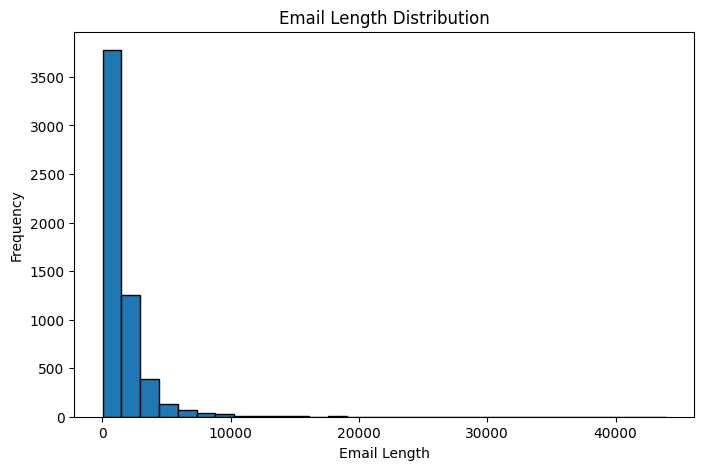

In [17]:
plt.figure(figsize=(8,5))

plt.hist(df["Length"], bins=30, edgecolor="black")

plt.title("Email Length Distribution")
plt.xlabel("Email Length")
plt.ylabel("Frequency")

plt.show()

In [18]:
df.groupby("spam")["Length"].mean()

spam
0    1631.918119
1    1317.257310
Name: Length, dtype: float64

<Figure size 600x500 with 0 Axes>

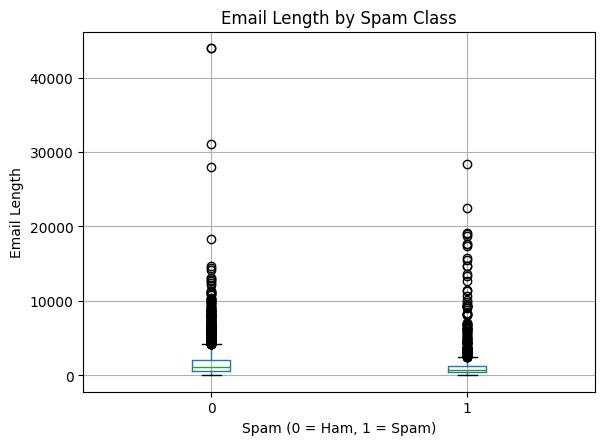

In [19]:
plt.figure(figsize=(6,5))

df.boxplot(column="Length", by="spam")

plt.title("Email Length by Spam Class")
plt.suptitle("")
plt.xlabel("Spam (0 = Ham, 1 = Spam)")
plt.ylabel("Email Length")

plt.show()

In [20]:
print("Total Emails :", len(df))
print("Spam Emails  :", (df["spam"] == 1).sum())
print("Ham Emails   :", (df["spam"] == 0).sum())

Total Emails : 5728
Spam Emails  : 1368
Ham Emails   : 4360
